# Hypothesis engines — status, results, and what each can honestly claim

**Notebook 05.** The five research channels (H1–H5), each with its freeze class and what it
has actually produced. **The pre-registration ledger is now frozen** — this notebook reads
its real state below and labels every claim accordingly.

LEDGER FROZEN at 2026-07-29T05:20:00+00:00
  h1_term_structure      freeze_class=X  status=exploratory
  h2_index_access        freeze_class=X  status=exploratory
  h3_letf_loop           freeze_class=X  status=exploratory
  h4_vol_decomposition   freeze_class=X  status=exploratory
  h5_quota_ledger        freeze_class=C  status=frozen
\nClass C = registered (H5). Class X = exploratory (H1-H4). Class P = empty (no prior commit).


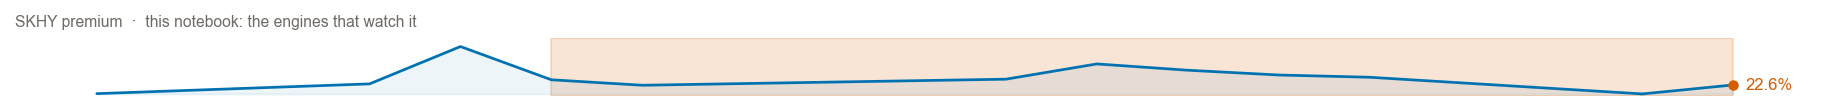

In [1]:
%matplotlib inline
import sys, subprocess, yaml, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
calls = yaml.safe_load((ROOT/"preregistration"/"calls.yaml").read_text())
print("LEDGER FROZEN at", calls.get("frozen_at"))
for h in ("h1_term_structure","h2_index_access","h3_letf_loop","h4_vol_decomposition","h5_quota_ledger"):
    print(f"  {h:22s} freeze_class={calls[h].get('freeze_class')}  status={calls[h]['status']}")
print("\\nClass C = registered (H5). Class X = exploratory (H1-H4). Class P = empty (no prior commit).")
from pipeline.viz import theme; theme.apply()
_pi = __import__("pipeline.measurement.premium", fromlist=["build_all_variants"]).build_all_variants("skhy")[0].series
theme.sparkline_header(_pi, highlight=("2026-07-15","2026-07-28"), label="SKHY premium  ·  this notebook: the engines that watch it");

## H5 — barrier-state monitor (Class C, **registered**)

The one pre-registered call. Its observable, live, with the scope limit on every output.

In [2]:
from hypotheses.h5_quota_ledger.monitor import status_report
print(status_report())

H5 — BARRIER-STATE LEDGER
skhynix_dr_headroom_capped  (US78392B2060)
  observations : 1   2026-07-15 .. 2026-07-15
  headroom     : 0
  flow         : no movement observed — level has never changed in sample
  ! headroom is ZERO — the barrier reads SEALED at this observation.
  ! single observation: KSD appears to publish only on change, so this is consistent with 'has not moved' rather than 'not published'. The control programme distinguishes the two.

skhynix_dr_headroom_legacy  (US78392B1070)
  observations : 1260   2010-03-31 .. 2026-07-28
  headroom     : 129,711,611
  flow         : 502 creation(s), 757 consumption(s)
  latest move  : +590

PUBLICATION CHECK
  PUBLISHING — control printed to 2026-07-28 while the capped programme's last print is 2026-07-15. The feed is live, so the capped programme has NOT MOVED. Barrier remains sealed by observation, not by absence of data.

CONTROL-PROGRAMME EPISODES ≥0.25% of level: 33

----------------------------------------------------------

The publication check is the substantive line: the capped programme's silence since
2026-07-15 is disambiguated by the control printing through 07-28 — so the barrier is
**sealed by observation, not by a dead feed.** The registered criterion carries an
INDETERMINATE branch for the case where headroom moves but no deposit clears, because
measured headroom is not the operative consent gate.

## H4 — realized variance decomposition (Class X, exploratory)

Exact log identity; the covariance terms reported, not folded away. The contrast between
pairs is the finding, not the SKHY level.

In [3]:
from hypotheses.h4_vol_decomposition.realized import compare_pairs
vd = compare_pairs()
vd[["pair","n","ann_vol_adr_pct","share_local","share_fx","share_pi","share_cov_local_pi","residual"]]

,pair,n,ann_vol_adr_pct,share_local,share_fx,share_pi,share_cov_local_pi,residual
0,skhy,11,184.22,0.5952,0.0017,0.7790,-0.3399,5.204170e-18
1,tsmc,6771,53.90,0.5222,0.0102,1.0066,-0.5473,4.336809e-19
2,baba,1592,49.44,0.9990,0.0002,0.9453,-0.9460,0.000000e+00


Premium variance is comparable to — for TSM slightly exceeds — total ADR variance, offset
by a strongly negative local-premium covariance: the premium **absorbs** local moves. BABA,
the fungible control, shows near-total cancellation (local 0.999, cov −0.946).

## M3 — convergence dynamics per regime class (PROVISIONAL)

Jordà local projections, HAC errors, SKHY forward-scored never fitted. **The deliverable
that gates the trade-sheet work.**

In [4]:
from pipeline.convergence.jorda import run_panel, metrics_table, score_skhy
res = run_panel()
metrics_table(res)

,regime,n_pairs,n_obs,horizon,rho,t_HAC,r2,n_eff,half_life_days,half_life_lo,half_life_hi,half_life_support,PROVISIONAL
0,fungible,6,27909,1,0.8723,14.85,0.7636,27903.0,4.2,2.5,9.7,interpolated,pending taxonomy ratification
1,fungible,6,27909,5,0.4014,3.04,0.1641,5575.8,4.2,2.5,9.7,interpolated,pending taxonomy ratification
2,fungible,6,27909,20,0.1970,1.67,0.0418,1389.5,4.2,2.5,9.7,interpolated,pending taxonomy ratification
3,one_way_constrained,4,18589,1,0.9787,211.27,0.9587,18585.0,310.1,217.1,unbounded,interpolated,pending taxonomy ratification
4,one_way_constrained,4,18589,5,0.9646,131.10,0.9372,3713.8,310.1,217.1,unbounded,interpolated,pending taxonomy ratification
5,one_way_constrained,4,18589,20,0.9402,62.14,0.9012,925.5,310.1,217.1,unbounded,interpolated,pending taxonomy ratification


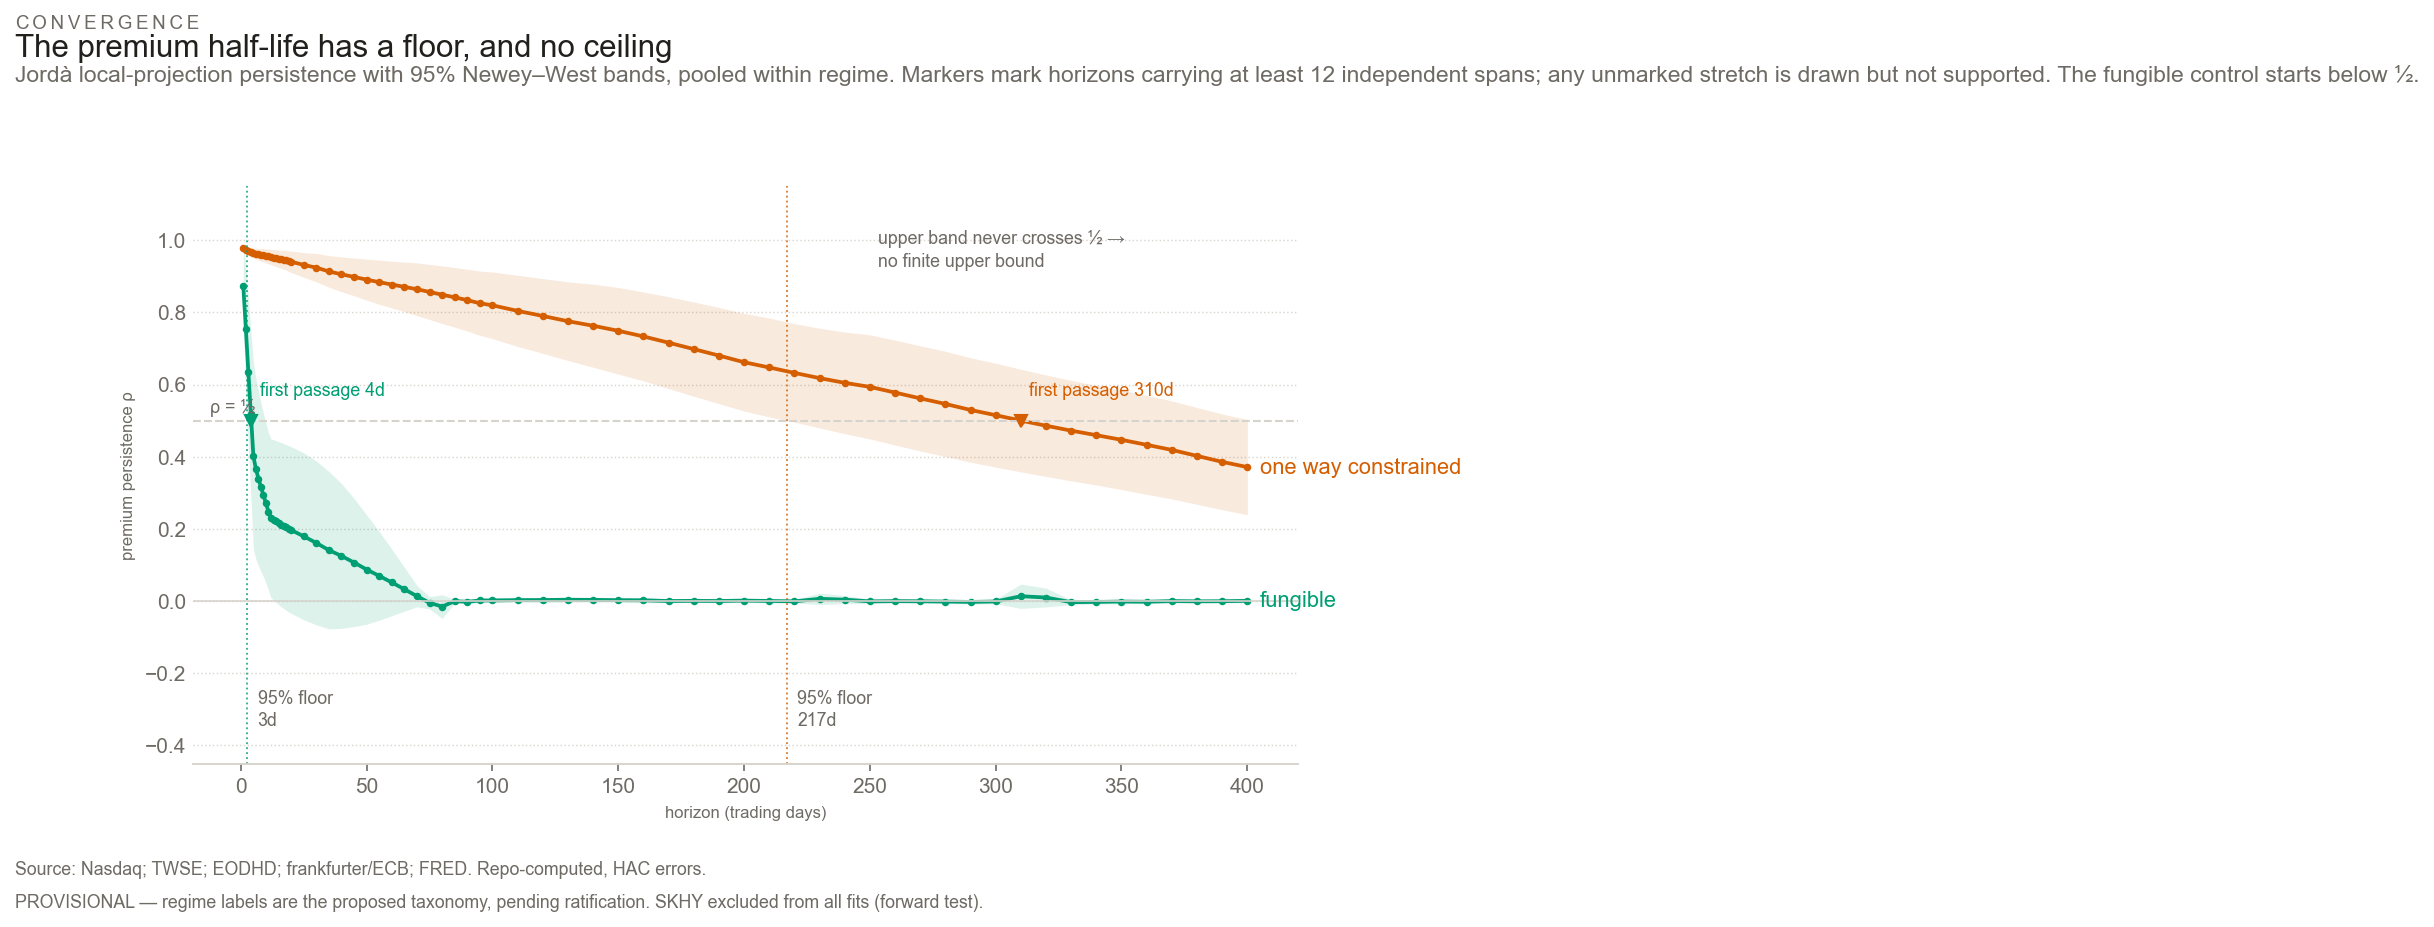

In [5]:
from pipeline.viz import figures
fig, ax = figures.g_convergence(res)
fig;

**In plain terms**

- Gaps like this one close slowly. Ones where the trade works both ways close within days.
- Best case, on the evidence, is about ten and a half months. There is no worst case we can rule
  out — the data cannot say the gap ever halves.
- Anything you pay per day, you should assume you pay for at least ten months.

**Read as the reflected-process thesis in a convergence estimate.** `one_way_constrained`
(TSM): ρ ≈ 0.94 one day out, still 0.88 at twenty days, t-HAC 129 — persistence on a scale
of **months**. `fungible` (BABA): ρ ≈ 0.04, statistically insignificant — same-week noise
around parity. The identical estimator produces both.

**The half-life is an interval with an open end, and that is the S17 result.** Through S15
the window stopped at h=20, ρ never approached ½ inside it, and the reported ~227d came from
extrapolating an exponential fit. Extending to h=400 was meant to make the crossing
observable. It did — and the observation contradicted the extrapolation in the direction that
matters:

- First passage of ρ below ½ is at **h ≈ 331**, roughly **46% slower** than the extrapolation
  claimed. The extrapolation was optimistic.
- The 95% band's **upper edge never crosses ½ at any estimable horizon**, so there is **no
  finite upper bound** — these data do not reject a premium that never halves.
- The band's lower edge crosses at **h ≈ 143**, where coefficients are still identified. That
  floor is the defensible number.

So extending the horizon did not turn an extrapolation into an estimate. It turned a false
point into a **floor with an open tail** — which is what any quantity linear in holding
horizon, financing cost above all, has to be quoted against.

**S18 then took the constrained class from one pair to four.** S17 named single-pair
dependence as the binding constraint, and it was: with only TSMC, "barrier regimes are
persistent" and "TSMC is persistent" were the same statement.

Membership is assigned from the **documented re-issuance rule, before any persistence is
estimated.** All four Taiwanese pairs run on one ROC rule — a *revolving* facility, where
re-issuance is permitted only within the scope of previously cancelled shares — which TSMC's
FY2024 20-F states directly and which Chunghwa Telecom's FY2025 20-F goes further on, drawing
the price conclusion itself. AU Optronics carries the same rule but is **excluded**: it
delisted its ADSs from the NYSE in 2019, and a premium built on the thin OTC successor
measures quote staleness as much as mispricing.

Three things changed, and one did not:

- The crossing became **identified** rather than underpowered — enough independent spans now
  sit under it.
- The 95% floor **rose from 143 to 220 trading days** (~7 months to ~10½). More evidence made
  the constraint tighter *and* more demanding, not looser.
- Per-pair ρ₁ runs 0.82–0.99 across the four, so the persistence **replicates** rather than
  resting on one issuer.
- **The open upper tail survived.** Roughly four times the data did not produce a finite upper
  bound. That is now a robust result rather than a small-sample artefact.

⚠️ **The limitation, stated where the estimate is:** these four share a regulator. Four pairs
reduce *issuer*-idiosyncratic noise; they do not give independent variation in the *rule*. A
second jurisdiction is the remaining gap — and India, the obvious candidate, turns out to be
the wrong one: its headroom regime was repealed effective 15 December 2014.

## The taxonomy, ratified

S19 discharges the `PROVISIONAL` flag that every M3 result had carried. The reason it could
not be discharged earlier is simple: with one pair per class, "the class is persistent" and
"this pair is persistent" are the same sentence. A taxonomy over two elements is a pair of
names. The constrained class now holds four and the control class six — Brazil, the
literature's standard control, where **Resolução Conjunta BCB/CVM nº 13/2024 imposes no
quantity cap on DR issuance.**

The rule is in `docs/regime_taxonomy.md` and is four steps. **Every step reads a filing. No
step reads a price** — classifying on the observed premium and then measuring the premium's
persistence would be a circle.

**Two corrections it makes, both load-bearing.**

*An exhausted ownership limit does not produce a premium; an exhausted programme cap does.*
Korea is the natural experiment: KT reports foreign ownership at **49.0% against a 49%
statutory ceiling — fully exhausted — and its ADR trades at about +1%.** KEPCO's 20-F lists
depositary issuance among the circumstances in which its 40% ceiling may be *exceeded*. So
the label attaches to the DR issuance mechanism, never to a foreign-ownership cap.

*Regime is a rule; binding-ness is a state.* `one_way_constrained` says the valve is
one-directional, not that it is currently shut. A reflected process sits at its barrier only
when something pushes it there — which is why this class contains pairs that have spent most
of their lives near parity. Binding-ness is observed separately, as shares-on-deposit over
programme cap, and that is what H5 monitors.

In [6]:
from pipeline.convergence.jorda import REGIME_OF_PAIR, CONSTRAINT_SUBTYPE, TAXONOMY_RATIFIED, PANEL_CAVEATS, estimate_regime
from pipeline.measurement.premium import build_all_variants
from pipeline.viz import figures
print(f"TAXONOMY RATIFIED {TAXONOMY_RATIFIED}   (docs/regime_taxonomy.md)")
print(f"{'pair':6s} {'regime':22s} {'sub-type':10s} {'n':>6s} {'mean pi':>9s} {'half-life':>10s}")
_rows = []
for pid, rg in REGIME_OF_PAIR.items():
    s_ = build_all_variants(pid)[0].series
    hl = estimate_regime([s_], rg).hl.point
    _rows.append({"pair": pid, "regime": rg, "mean": float(s_.mean()), "half_life": hl})
    print(f"{pid:6s} {rg:22s} {CONSTRAINT_SUBTYPE.get(pid,'-'):10s} {len(s_):6d} "
          f"{s_.mean():+8.2%} {hl:9.0f}d")
print()
print("PANEL CAVEATS (the taxonomy is ratified; the panel is not):")
for c in PANEL_CAVEATS: print("  !", c)

TAXONOMY RATIFIED 2026-07-29   (docs/regime_taxonomy.md)
pair   regime                 sub-type        n   mean pi  half-life
tsmc   one_way_constrained    revolving    5064   +6.24%       236d
umc    one_way_constrained    revolving    6156  +14.92%       312d
ase    one_way_constrained    revolving    1918   +1.96%       161d


cht    one_way_constrained    revolving    5451   +3.91%       398d
baba   fungible               -            1593   -0.17%         1d
vale   fungible               -            5929   +0.81%         5d
itub   fungible               -            4984   +0.10%         3d


abev   fungible               -            4496   +0.10%         2d
pbr    fungible               -            4495   +0.25%         3d
ggb    fungible               -            6412   -0.91%        24d

PANEL CAVEATS (the taxonomy is ratified; the panel is not):
  ! constrained class is four issuers under ONE regulator -- reduces issuer noise, gives no independent variation in the rule
  ! fungible class is five Brazilian pairs plus Alibaba -- one country dominates the control


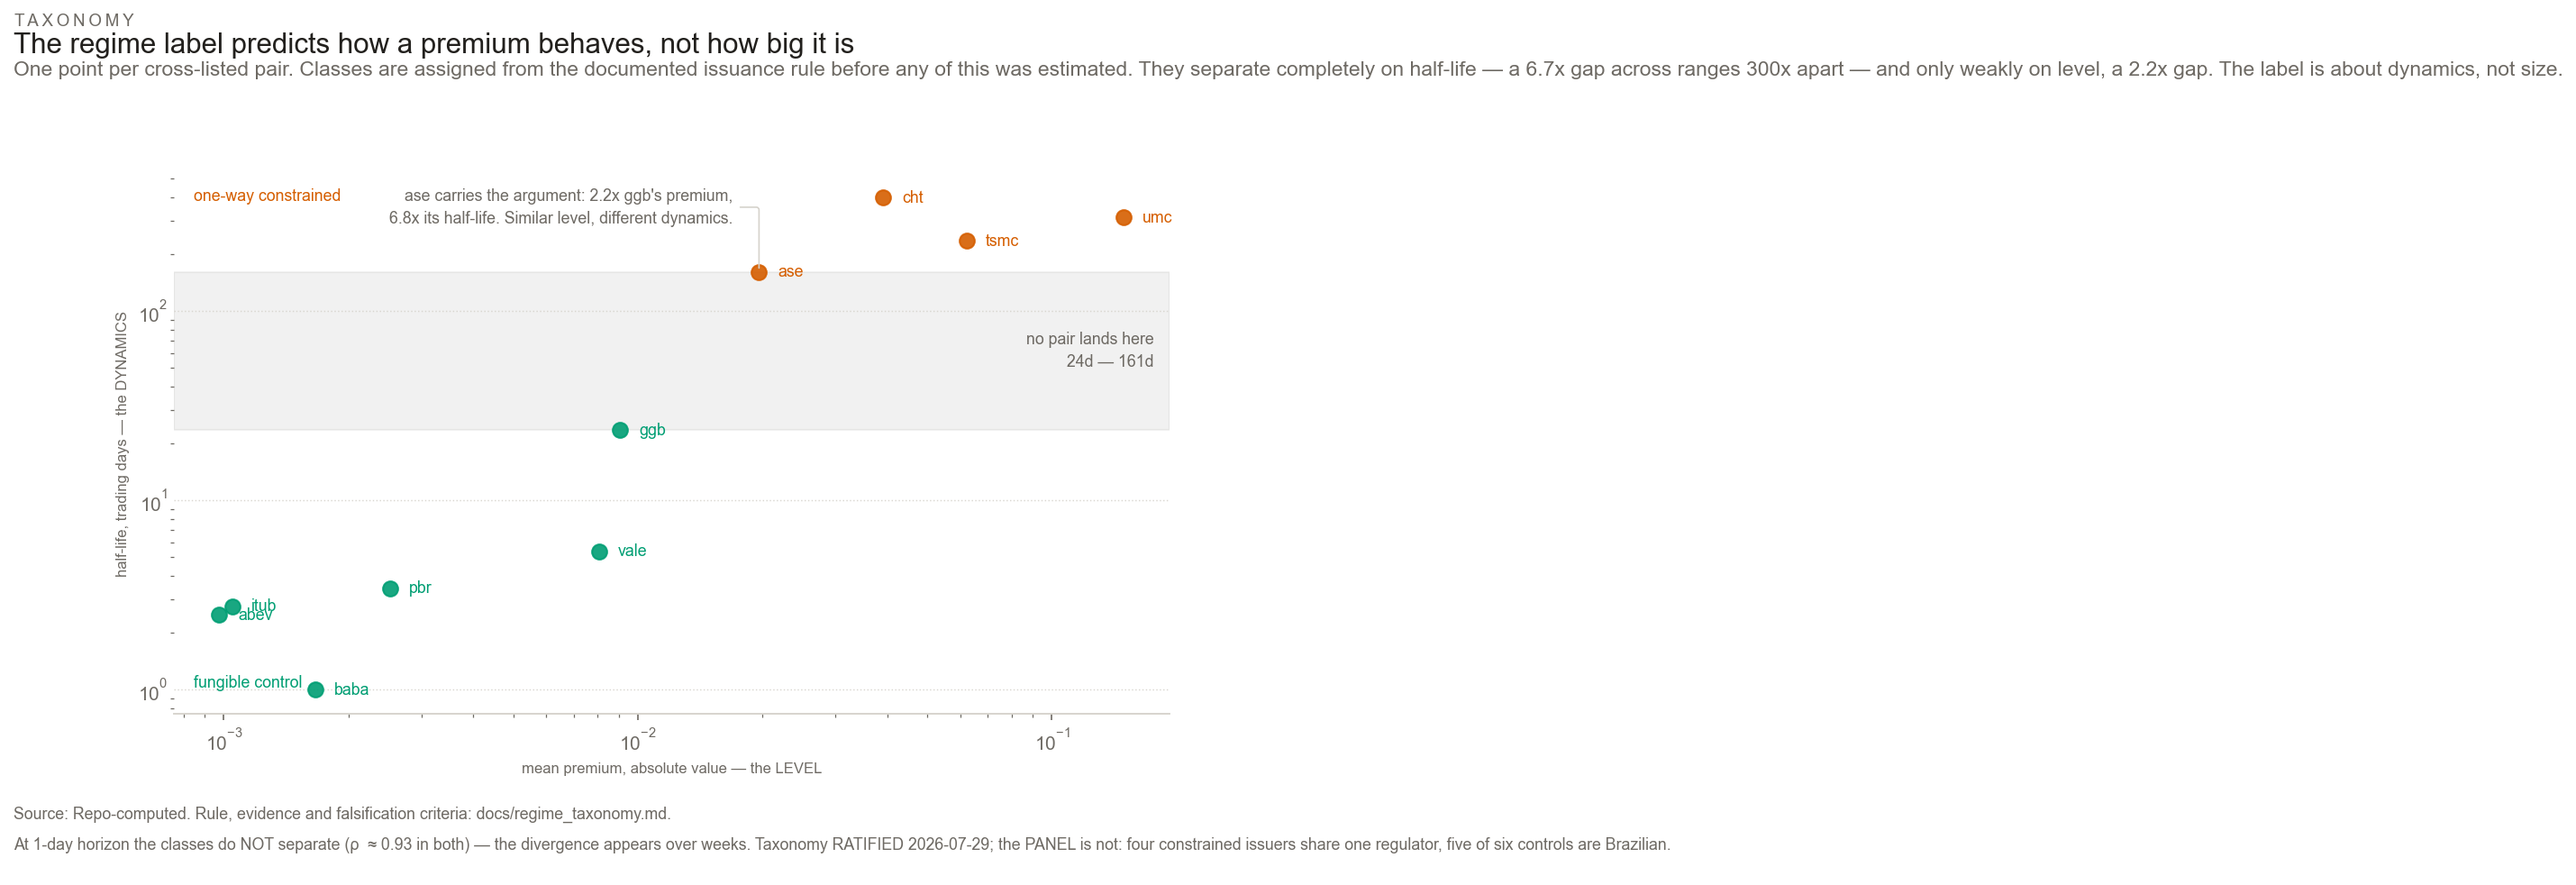

In [7]:
fig, ax = figures.g11_taxonomy_separation(_rows)
fig;

**In plain terms**

- Sort cross-listings by whether the trade works both ways, using only the legal documents. Then
  look at how their gaps behave.
- The one-way ones take months to close. The two-way ones take days. Nothing sits in between.
- That sorting was done before looking at any prices, which is why it is a finding and not a
  circular argument.

The classes separate **completely on half-life** — constrained 161–398 trading days, controls
1–24, with nothing in between — and only weakly on level, a 2.2× gap. ASE carries the argument
by itself: a mean premium roughly twice the largest control's, and a half-life roughly seven
times it. Same neighbourhood on size, an order of magnitude apart on behaviour.

**And a caution the figure states in its own footnote:** at *one-day* horizon the classes do
not separate at all (ρ₁ ≈ 0.93 for both a constrained and a control pair). The divergence
appears only over weeks. Choosing the wrong horizon would have made this taxonomy look
worthless.

One honesty note on the controls. Several Brazilian pairs carry episodic ratio contamination
that survives the sample restrictions — multi-day runs of extreme values that I can detect but
cannot attribute to documented corporate actions without more filing work. They are left **as
landed**, because cleaning them *lowers* control persistence (ρ₁ 0.87 → 0.34, half-life 4d →
under 1d). The contaminated number is therefore the conservative one: it makes the contrast
look smaller than it is, so reporting it cannot flatter the result.

In [8]:
from pipeline.convergence.jorda import REGIME_OF_PAIR
from pipeline.measurement.premium import build_all_variants
print("PER-PAIR, constrained class (pooled membership assigned from the rule, not the data)")
print(f"{'pair':6s} {'n':>6s} {'mean pi':>9s} {'min':>8s} {'max':>8s}")
for pid, rg in REGIME_OF_PAIR.items():
    if rg != "one_way_constrained": continue
    s_ = build_all_variants(pid)[0].series
    print(f"{pid:6s} {len(s_):6d} {s_.mean():+8.2%} {s_.min():+8.2%} {s_.max():+8.2%}")
print()
for regime, r in res.items():
    print(f"{regime:22s} half-life {r.hl.describe()}")
    print(f"{'':22s} {r.hl.method}")
    for n in r.notes: print("   !", n)
sk = score_skhy()
print(f"\\nSKHY: {sk['n_obs']} obs — {sk['out_of_support']}")
print(f"  {sk['note']}")
print(f"  resolution: {sk['resolution']}")

PER-PAIR, constrained class (pooled membership assigned from the rule, not the data)
pair        n   mean pi      min      max
tsmc     5064   +6.24%   -7.85%  +32.86%
umc      6156  +14.92%  -17.17% +124.33%
ase      1918   +1.96%   -9.57%  +19.26%
cht      5451   +3.91%  -24.77% +121.01%

one_way_constrained    half-life 310d  [95% 217d .. unbounded]  interpolated
                       first passage of ρ below ½ (in window)
   ! NO FINITE UPPER BOUND. The upper 95% edge of ρ_h stays above ½ across every estimable horizon (to h=400), so the data do not reject a premium that never halves. Any quantity linear in holding horizon — financing cost above all — inherits an unbounded upper tail and must be quoted as a floor, never a point.
   ! Lower bound 217d is the FASTEST convergence consistent with the data at 95%, and it is the defensible number: it sits where the coefficients are still identified.
fungible               half-life 4d  [95% 3d .. 10d]  interpolated
                     

## H1, H2, H3 — status (all Class X, exploratory; data-blocked)

| | channel | blocker |
|---|---|---|
| **H1** | term-structure RV | no sanctioned listed-derivatives source landed |
| **H2** | synthetic index access | venue reframed (Eurex terminated); KRX night-session separability unverified |
| **H3** | LETF close-imbalance | **no landed AUM** — issuer pages are JS SPAs, the data-bearing Naver route is terms-withheld |

H3's rebalance-notional estimator has no AUM input, so its power analysis is moot until an
AUM series lands. This is data-blocked, not a null result — the distinction matters.

## What this notebook does not claim

Nothing here is a blind pre-event forward test — **Class P is empty** (no call predates the
2026-07-29 release on the record). H5 is registered post-earnings, pre-flow, with earnings
acknowledged as known context. The convergence table is a **two-regime contrast**, not a
four-regime sweep — the `two_way_headroom` middle is empty (India unavailable). All of this
is stated rather than smoothed.